In [2]:
import pandas as pd
import requests
import json
import folium
import geopandas as gpd
from dotenv import load_dotenv
import os

In [11]:
# 1. 현재 경로의 .env 파일 로드
load_dotenv()

# 2. 환경 변수 읽기
SEOUL_OPEN_API = os.getenv("SEOUL_OPEN_API")
V_WORLD_API = os.getenv("V_WORLD_API")

# 1. 서울열린데이터광장 API - 구 목록 수집

In [12]:
API_KEY = SEOUL_OPEN_API
service = 'SearchFAQOfGUListService' 
gu_url = f'http://openapi.seoul.go.kr:8088/{API_KEY}/json/{service}/1/25'
gu_list = requests.get(gu_url).json()

In [13]:
# 구 목록을 데이터프레임으로 저장
df_gu = pd.DataFrame(gu_list['SearchFAQOfGUListService']['row'])

# 2. V-WORLD API - 구단위 경계 좌표 수집

In [14]:
gu_json = []
vwolrd_key = V_WORLD_API
for gu in df_gu['CD_DESC']:
    url_vworld = f'https://api.vworld.kr/req/data?service=data&version=2.0&request=GetFeature&format=json&errorformat=json&size=10&page=1&data=LT_C_ADSIGG_INFO&attrfilter=sig_kor_nm:like:{gu}&columns=sig_cd,full_nm,sig_kor_nm,sig_eng_nm,ag_geom&geometry=true&attribute=true&key={vwolrd_key}&domain=https://localhost'
    result_dict = requests.get(url_vworld).json()
    gu_json.append(result_dict)

## GeoJSON 파일 생성 및 저장

In [15]:
# 서울시 25개 구의 경계 데이터 수집 및 합치기
features = []
for gu_data in gu_json:  # gu_json 25개 구의 API 응답 데이터 리스트
   gu_name = gu_data['response']['result']['featureCollection']['features'][0]['properties']['sig_kor_nm']
   feature = {
       "type": "Feature",
       "id": gu_name,  # 구명을 id로 추가
       "geometry": gu_data['response']['result']['featureCollection']['features'][0]['geometry'],
       "properties": {
           "name": gu_name
       }
   }
   features.append(feature)

geojson_data = {
   "type": "FeatureCollection",
   "features": features
}

In [16]:
# GeoJSON 파일 저장
with open('../data_bigCon/seoul_gu_boundaries.geojson', 'w', encoding='utf-8') as f:
    json.dump(geojson_data, f, ensure_ascii=False)

# 3. 서울열린데이터광장 API - 역사마스터 정보 수집

In [17]:
API_KEY = SEOUL_OPEN_API
service = 'subwayStationMaster' 

# 1건만 요청해서 전체 개수 파악
check_url = f'http://openapi.seoul.go.kr:8088/{API_KEY}/json/subwayStationMaster/1/1/'
res = requests.get(check_url)
data = res.json()

total_count = data['subwayStationMaster']['list_total_count']
print("총 역사 수:", total_count)

총 역사 수: 783


In [18]:
# 총 개수를 넣어서 전체 요청
full_url = f'http://openapi.seoul.go.kr:8088/{API_KEY}/json/subwayStationMaster/1/{total_count}/'
res = requests.get(full_url)
data = res.json()

# 데이터 리스트
stations = data['subwayStationMaster']['row']
stations_df = pd.DataFrame(stations)

stations_df.to_csv('../data_bigCon/station_master.csv')
print(len(stations_df))
stations_df.head()

783


,BLDN_ID,BLDN_NM,ROUTE,LAT,LOT
0,0150,서울역,1호선,37.556228,126.972135
1,0151,시청,1호선,37.565715,126.977088
2,0152,종각,1호선,37.570161,126.982923
3,0153,종로3가,1호선,37.570406,126.991847
4,0154,종로5가,1호선,37.570926,127.001849


In [19]:
# 위도, 경도 컬럼 float 변환 (에러나면 NaN 처리)
stations_df['LAT'] = pd.to_numeric(stations_df['LAT'], errors='coerce')
stations_df['LOT'] = pd.to_numeric(stations_df['LOT'], errors='coerce')

# 4. V-WORLD API - 동단위 경계 좌표 수집¶

## 4-1. 전국단위 동 경계 정보 불러오기

In [20]:
# shp 파일 경로
shp_path = '../data_bigCon/BND_ADM_DONG_PG/BND_ADM_DONG_PG.shp'

# shapefile 읽기 (인코딩 문제시 encoding 파라미터 조정)
dong_gdf = gpd.read_file(shp_path)

# 데이터 구조 확인
dong_gdf.head(3)

,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20240630,24010510,충장동,"POLYGON ((192642.941 284096.719, 192642.09 284..."
1,20240630,24010540,동명동,"POLYGON ((193270.372 284034.819, 193270.194 28..."
2,20240630,36680400,안좌면,"MULTIPOLYGON (((113338.23 243273.44, 113342.37..."


## 4-2. 성동구 동명만 필터링

In [21]:
# 성동구의 동 이름 가져오기
dong_codes = pd.read_excel('../data_bigCon/BND_ADM_DONG_PG/센서스 공간정보 지역 코드.xlsx', header=1)

# '시군구명칭'이 '성동구'인 행에서 '읍면동명칭'만 리스트로 추출
seongdong_dongs = dong_codes[dong_codes['시군구명칭'] == '성동구']['읍면동명칭'].tolist()

# Shapefile에서 해당 동 이름만 필터링
seongdong_gdf = dong_gdf[dong_gdf['ADM_NM'].isin(seongdong_dongs)]

# folium용 GeoJSON 변환
seongdong_geojson = seongdong_gdf.to_crs(epsg=4326).to_json()

# 5. 빅콘 데이터셋

## 원 데이터로부터 위치 정보 필터링
- 주이님 께서 병합 데이터 제공

In [22]:
dataSet_1_geo = pd.read_csv('../data_bigCon/big_data_set1_jui.csv',encoding='cp949')

In [23]:
dataSet_1_geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4183 entries, 0 to 4182
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ENCODED_MCT         4183 non-null   object 
 1   MCT_NM              4183 non-null   object 
 2   MCT_BRD_NUM         542 non-null    object 
 3   MCT_SIGUNGU_NM      4183 non-null   object 
 4   HPSN_MCT_ZCD_NM     4183 non-null   object 
 5   HPSN_MCT_BZN_CD_NM  3137 non-null   object 
 6   ARE_D               4183 non-null   int64  
 7   MCT_ME_D            127 non-null    float64
 8   DONG                4183 non-null   object 
 9   ADDR_ROAD           4183 non-null   object 
 10  ADDR_JIBUN          4183 non-null   object 
 11  LAT                 4183 non-null   float64
 12  LON                 4183 non-null   float64
dtypes: float64(3), int64(1), object(9)
memory usage: 425.0+ KB


## 가맹점 별 반경(200m, 500m, 800m)내 지하철 역 개수 기반 점수

In [24]:
from sklearn.neighbors import BallTree
import numpy as np

In [25]:
stations_df[['LAT', 'LOT']].isna().sum()

LAT    0
LOT    0
dtype: int64

In [26]:
dataSet_1_geo[['LAT', 'LON']].isna().sum()

LAT    0
LON    0
dtype: int64

In [27]:
# NaN 제거 또는 처리 (필요에 따라)
stations_df = stations_df.dropna(subset=['LAT', 'LOT'])
dataSet_1_geo = dataSet_1_geo.dropna(subset=['LAT', 'LON'])

In [28]:
# 지하철역 좌표 (위도, 경도 → radians)
station_coords = np.radians(stations_df[['LAT', 'LOT']].values)

# 가맹점 좌표 (위도, 경도 → radians)
shop_coords = np.radians(dataSet_1_geo[['LAT', 'LON']].values)

In [29]:
# BallTree 생성 (haversine 거리 사용)
tree = BallTree(station_coords, metric='haversine')

In [30]:
# 거리 반경 (미터 → 라디안 변환 필요)
radius_200 = 200 / 6371000  # 지구 반지름: 6371km
radius_500 = 500 / 6371000
radius_800 = 800 / 6371000

# 반경 내 지하철역 인덱스 찾기
indices_200 = tree.query_radius(shop_coords, r=radius_200)
indices_500 = tree.query_radius(shop_coords, r=radius_500)
indices_800 = tree.query_radius(shop_coords, r=radius_800)

# 개수 저장
dataSet_1_geo = dataSet_1_geo.copy()
dataSet_1_geo['station_cnt_200m'] = [len(i) for i in indices_200]
dataSet_1_geo['station_cnt_500m'] = [len(i) for i in indices_500]
dataSet_1_geo['station_cnt_800m'] = [len(i) for i in indices_800]

In [31]:
dataSet_1_geo.head(3)

,ENCODED_MCT,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,DONG,ADDR_ROAD,ADDR_JIBUN,LAT,LON,station_cnt_200m,station_cnt_500m,station_cnt_800m
0,16184E93D9,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6
1,4D039EA8B7,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6
2,0074C4990A,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6


In [32]:
# 반경내 역 개수 별 가중치 설정
w200, w500, w800 = 0.5, 0.3, 0.2  # 가까운 역에 더 높은 가중치

# 반경 내 최대값 정규화를 위해 각 컬럼의 최대값 추출
max_200 = dataSet_1_geo['station_cnt_200m'].max()
max_500 = dataSet_1_geo['station_cnt_500m'].max()
max_800 = dataSet_1_geo['station_cnt_800m'].max()

# 0~1값 사이의 점수 (정규화 + 가중 평균)
dataSet_1_geo['station_access_score'] = (
    (dataSet_1_geo['station_cnt_200m'] / max_200) * w200 +
    (dataSet_1_geo['station_cnt_500m'] / max_500) * w500 +
    (dataSet_1_geo['station_cnt_800m'] / max_800) * w800
)

In [33]:
dataSet_1_geo.head(3)

,ENCODED_MCT,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,DONG,ADDR_ROAD,ADDR_JIBUN,LAT,LON,station_cnt_200m,station_cnt_500m,station_cnt_800m,station_access_score
0,16184E93D9,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667
1,4D039EA8B7,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667
2,0074C4990A,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667


## KNN활용 가장 가까운 지하철 역 5개의 거리 기반 점수

In [34]:
# 지하철역 좌표 (위도, 경도 → radians) - 이미 위에서 구함
# station_coords,  shop_coords는 위에서 구한 값 사용

# BallTree 생성
tree = BallTree(station_coords, metric='haversine')

In [35]:
# KNN 검색
k = 5  # 가장 가까운 역 5개

# 각 가맹점별로 k개의 가장 가까운 역 거리 (단위: radian)
distances, indices = tree.query(shop_coords, k=k)

# 거리(m) 단위로 변환 (지구 반지름 = 6371km)
distances_m = distances * 6371000

In [36]:
# 역 거리들의 역수 평균으로 점수화
proximity_scores = 1 / (distances_m + 1)
score_avg = proximity_scores.mean(axis=1)

# 결과를 DataFrame에 추가
dataSet_1_geo['KNN_score'] = score_avg

In [37]:
dataSet_1_geo.head(3)

,ENCODED_MCT,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,DONG,ADDR_ROAD,ADDR_JIBUN,LAT,LON,station_cnt_200m,station_cnt_500m,station_cnt_800m,station_access_score,KNN_score
0,16184E93D9,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667,0.003908
1,4D039EA8B7,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667,0.003908
2,0074C4990A,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667,0.003908


# Figure. 지도 시각화

In [38]:
# 호선별 색상 매핑
line_colors = {
    '1호선': 'darkblue',
    '경인선': 'darkblue',
    '경부선': 'darkblue',
    '장항선': 'darkblue',
    '경원선': 'darkblue',
    '2호선': 'green',
    '3호선': 'orange',
    '4호선': 'lightblue',
    '5호선': 'darkpurple',
    '6호선': 'darkred',
    '7호선': 'darkgreen',
    '8호선': 'pink',
    '9호선': 'beige',
    '9호선(연장)': 'beige',
    '수도권 광역급행철도': 'red'
}

In [39]:
def map_station_geo(sample_index=42):
    # 지도 생성
    tiles = ['cartodbpositron', 'cartodb dark_matter', 'OpenStreetMap']
    
    m = folium.Map(
        location=[37.5651, 126.98955], 
        zoom_start=11,
        tiles=tiles[0]
    )
    
    # GeoJSON 데이터 불러오기
    with open('../data_bigCon/seoul_gu_boundaries.geojson', encoding='utf-8') as f:
        geojson_data = json.load(f)
    
    # 스타일 함수 정의
    def style_function(feature):
        if feature['properties']['name'] == '성동구':
            return {
                'fillColor': 'yellow',
                'color': 'black',
                'weight': 1.2,
                'fillOpacity': 0.3,
                'dashArray': '4, 6'
            }
        else:
            return {
                'fillColor': 'transparent',  # 또는 'white'
                'color': 'black',
                'weight': 1,
                'fillOpacity': 0,            # 내부 채우기 없음
                'dashArray': '4, 6'
            }
    
    # GeoJson 레이어 추가 + 구 이름 툴팁
    folium.GeoJson(
        geojson_data,
        name="서울시 구 경계",
        style_function=style_function,
        tooltip=folium.GeoJsonTooltip(
            fields=['name'],              # 구 이름
            aliases=['구 이름:'],        # 툴팁에 표시할 라벨
            localize=True
        )
    ).add_to(m)
    
    # 각 역 위치에 마커 추가
    for _, row in stations_df.iterrows():
        line = row['ROUTE'] # 호선
        color = line_colors.get(line, 'gray') # 호선별 색상
        
        folium.Marker(
            location=[row['LAT'], row['LOT']],
            popup=f'{row["BLDN_NM"]} ({row["ROUTE"]})',
            tooltip=row['BLDN_NM'],
            icon=folium.Icon(color=color, icon='subway', prefix='fa')  # 예: 빨간 마커 + 기차 아이콘
        ).add_to(m)
    
    # 행정동 경계 추가
    folium.GeoJson(
        seongdong_geojson,
        name='성동구 행정동 경계',
        style_function=lambda x: {
            'fillColor': '#ffffff00',  # 투명
            'color': 'orange',
            'weight': 1.5,
            'fillOpacity': 0,
            'dashArray': '2, 4'
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['ADM_NM'],
            aliases=['행정동:']
        )
    ).add_to(m)
    
    # 예시로 사용할 가맹점 표시
    sample_store = dataSet_1_geo.iloc[sample_index]
    store_lat = sample_store['LAT']
    store_lon = sample_store['LON']
    store_name = sample_store['MCT_NM']
    
    # 마커 추가 (가맹점)
    folium.Marker(
        location=[store_lat, store_lon],
        popup=f"{store_name} (예시 가맹점)",
        tooltip=store_name,
        icon=folium.Icon(color='red', icon='cutlery', prefix='fa')
    ).add_to(m)
    
    # 가맹점 중심으로 반경 원 추가
    folium.Circle(
        location=[store_lat, store_lon],
        radius=800,
        color='purple',
        fill=True,
        fill_opacity=0.05,
        popup='800m 반경'
    ).add_to(m)
    
    folium.Circle(
        location=[store_lat, store_lon],
        radius=500,
        color='green',
        fill=True,
        fill_opacity=0.07,
        popup='500m 반경'
    ).add_to(m)
    
    folium.Circle(
        location=[store_lat, store_lon],
        radius=200,
        color='blue',
        fill=True,
        fill_opacity=0.1,
        popup='200m 반경'
    ).add_to(m)
    
    # 지도 출력
    return m

In [42]:
map_station_geo(1042)

In [43]:
dataSet_1_geo.iloc[1042]

ENCODED_MCT                        70F032FFD5
MCT_NM                        로드*************
MCT_BRD_NUM                               NaN
MCT_SIGUNGU_NM                         서울 성동구
HPSN_MCT_ZCD_NM                         커피전문점
HPSN_MCT_BZN_CD_NM                        방배역
ARE_D                                20221027
MCT_ME_D                                  NaN
DONG                                    성수동1가
ADDR_ROAD                서울특별시 성동구 뚝섬로3길 11-5
ADDR_JIBUN              서울특별시 성동구 성수동1가 72-87
LAT                                 37.541179
LON                                127.049251
station_cnt_200m                            0
station_cnt_500m                            1
station_cnt_800m                            3
station_access_score                     0.16
KNN_score                            0.001232
Name: 1042, dtype: object

In [36]:
dataSet_1_geo.to_csv('../data_bigCon/dataSet_1_geo_station.csv')

In [37]:
dataSet_1_geo.head(3)

,ENCODED_MCT,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,DONG,ADDR_ROAD,ADDR_JIBUN,LAT,LON,station_cnt_200m,station_cnt_500m,station_cnt_800m,station_access_score,KNN_score
0,16184E93D9,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667,0.003908
1,4D039EA8B7,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667,0.003908
2,0074C4990A,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,마장동,서울특별시 성동구 마장로40길 3,서울특별시 성동구 마장동 790-16,37.565428,127.043,1,1,6,0.426667,0.003908


# 빅콘 데이터셋 오리지널

In [173]:
dataSet_1 = pd.read_csv('./data/big_data_set1_f.csv', encoding='cp949')
dataSet_1.head(3)

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN


In [175]:
len(dataSet_1)

4185

In [73]:
dataSet_2 = pd.read_csv('../data_bigCon/big_data_set2_f.csv', encoding='cp949')
dataSet_2.head(3)

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2


In [72]:
dataSet_3 = pd.read_csv('../data_bigCon/big_data_set3_f.csv', encoding='cp949')
dataSet_3.head(3)

,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


In [75]:
dataSet_4 = pd.read_csv('../data_bigCon/seoul_stations.csv', encoding='cp949')
dataSet_4.head(3)

,역사_ID,역사명,호선,위도,경도
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569
1,9009,구성,수도권 광역급행철도,37.29913,127.10389
2,9008,성남,수도권 광역급행철도,37.39467,127.12058


In [80]:
dataSet_5 = pd.read_csv('../data_bigCon/행정구역(동별)_20251015141944.csv')
dataSet_5

,동별(1),동별(2),동별(3),2024,2024.1,2024.2,2024.3,2024.4,2024.5
0,동별(1),동별(2),동별(3),면적,면적,동 (개소),동 (개소),통 (개소),반 (개소)
1,동별(1),동별(2),동별(3),면적 (k㎡),구성비 (%),행정,법정,소계,소계
2,서울시,소계,소계,605.25,100,426,467,12934,94795
3,서울시,종로구,소계,23.91,3.95,17,87,279,1475
4,서울시,종로구,사직동,1.23,0.2,1,12,16,68
...,...,...,...,...,...,...,...,...,...
449,서울시,강동구,둔촌1동,0.92,0.15,1,1,26,299
450,서울시,강동구,둔촌2동,1.56,0.26,1,-,29,262
451,서울시,강동구,강일동,2.26,0.37,1,1,40,317
452,서울시,강동구,상일1동,1.82,0.3,1,1,46,397


In [ ]:
dataSet_5_s

# 이전 EDA

In [3]:
customers = pd.read_csv('./data_bigCon/big_data_set2_f.csv', encoding='cp949')
customers.head()

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


In [4]:
transactions = pd.read_csv('../data_bigCon/big_data_set3_f.csv', encoding='cp949')
transactions.head()

,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


# 프로젝트 로드맵: 가맹점 매출 안정성 진단 + 매출 예측

## 1. 데이터셋 준비 & 전처리
- 데이터셋1 (가맹점 개요정보)
    - 업종(HPSN_MCT_ZCD_NM) / 상권(HPSN_MCT_BZN_CD_NM) / 개설일(ARE_D) / 폐업일(MCT_ME_D)
    - 활용: 업종·상권 분류, 가맹점 생애주기(개설~운영개월수)
- 데이터셋2 (월별 이용 정보)
    - 핵심 지표
        - 매출액(RC_M1_SAA)
        - 매출건수(RC_M1_TO_UE_CT)
        - 고객수(RC_M1_UE_CUS_CN)
        - 객단가(RC_M1_AV_NP_AT)
        - 배달 비율(DLV_SAA_RAT)
        - 취소율(APV_CE_RAT)
        - 업종·상권 내 순위(M12_SME_RY_SAA_PCE_RT, M12_SME_BZN_SAA_PCE_RT)
        - 업종/상권 내 해지율(M12_SME_RY_ME_MCT_RAT, M12_SME_BZN_ME_MCT_RAT)
    - 활용: 매출 안정성/경쟁력 지표 산출
- 데이터셋3 (월별 고객 정보)
    - 성별/연령대 고객 비중 (M12_MAL_30_RAT, M12_FME_40_RAT 등)
    - 재방문 고객 비중(MCT_UE_CLN_REU_RAT)
    - 신규 고객 비중(MCT_UE_CLN_NEW_RAT)
    - 거주/직장/유동 고객 비율(RC_M1_SHC_RSD_UE_CLN_RAT, RC_M1_SHC_WP_UE_CLN_RAT, RC_M1_SHC_FLP_UE_CLN_RAT)
    - 활용: 안정성에 영향을 주는 고객 특성 지표

## 2. 가맹점 매출 안정성 진단
- 목표: 안정형 vs 위험형 가맹점 구분
- 특징 추출
    - 매출 변동성: RC_M1_SAA 표준편차, 변동계수(CV)
    - 성장성: M1_SME_RY_SAA_RAT, M1_SME_RY_CNT_RAT
    - 시장 내 경쟁력: 업종/상권 내 순위(M12_SME_RY_SAA_PCE_RT, M12_SME_BZN_SAA_PCE_RT)
    - 고객 안정성: 재방문율(MCT_UE_CLN_REU_RAT), 연령/성별 분산도, 거주 vs 유동 고객 비율
- AI 모델 적용
    - 클러스터링 (K-means, GMM) → 안정형/위험형 그룹 자동 탐색
    - 분류 (XGBoost, LightGBM) → 안정형/위험형 예측 모델

- 결과:
    - 위험군 가맹점 리스트
    - 위험군 특징 (예: 배달 비율 높고 유동 고객 의존도 큰 가맹점)

## 3. 매출 예측 (시계열 모델)
- 목표: 향후 3~6개월 매출 예측
- 입력 데이터
    - RC_M1_SAA (월 매출액) + 계절성/트렌드 반영
    - 외생 변수: 객단가(RC_M1_AV_NP_AT), 배달 비율(DLV_SAA_RAT), 취소율(APV_CE_RAT), 고객구성(데이터셋3)
- AI 모델 적용
    - 전통 시계열: ARIMA (통계적 해석 용이),
    - 고도화: Prophet (트렌드+계절성 쉬운 반영)
    - 딥러닝 확장: LSTM / GRU (장기 패턴 학습)
    - (하이브리드: 업종별/상권별 군집화 → 그룹 단위 예측 → 개별 가맹점 Fine-tuning)

- 결과:
    - 매출 예측 곡선 (실제 vs 예측)
    - 성수기/비수기 탐지
    - 위험군 가맹점의 매출 감소 시점 사전 경고

## 4. 분석 결과 결합 (진단 → 예측 → 전략)
- 진단: 위험군 가맹점 탐지 (안정성 분석 결과)
- 예측: 해당 가맹점의 미래 매출 예측
- 전략 제안:
    - 고객 타겟팅: 특정 연령/성별 비중을 늘려야 하는지
    - 채널 전략: 배달 vs 오프라인 비율 조정
    - 운영 전략: 인력/재고 준비 시점 제안
    - 정책 활용: 지자체 지원금 집중 대상 업종/지역 추천

## 5. 최종 산출물(발표자료)
- 대시보드
    - 성동구 지도 위에 안정형(초록) vs 위험형(빨강) 가맹점 시각화
    - 매출 예측 그래프: “향후 3개월 매출 전망” + 성수기 표시
    - 고객 구조 차트: 안정형 vs 위험형 고객 특성 비교

- 정책 제안
    - 지자체: 지원 우선 업종/상권 제시
    - 가맹점주: 위험군 맞춤 매출 회복 전략
    - 카드사: 고객 혜택 설계 (연령·성별 맞춤 프로모션)

In [5]:
# 1. 가맹점 정보 붙이기
transactions_with_merchant = transactions.merge(merchants, on='ENCODED_MCT', how='left')

# 2. 고객 통계도 붙이기 (같은 월 기준으로)
full_data = transactions_with_merchant.merge(customers, on=['ENCODED_MCT', 'TA_YM'], how='left')

In [6]:
full_data.columns

Index(['ENCODED_MCT', 'TA_YM', 'M12_MAL_1020_RAT', 'M12_MAL_30_RAT',
       'M12_MAL_40_RAT', 'M12_MAL_50_RAT', 'M12_MAL_60_RAT',
       'M12_FME_1020_RAT', 'M12_FME_30_RAT', 'M12_FME_40_RAT',
       'M12_FME_50_RAT', 'M12_FME_60_RAT', 'MCT_UE_CLN_REU_RAT',
       'MCT_UE_CLN_NEW_RAT', 'RC_M1_SHC_RSD_UE_CLN_RAT',
       'RC_M1_SHC_WP_UE_CLN_RAT', 'RC_M1_SHC_FLP_UE_CLN_RAT', 'MCT_BSE_AR',
       'MCT_NM', 'MCT_BRD_NUM', 'MCT_SIGUNGU_NM', 'HPSN_MCT_ZCD_NM',
       'HPSN_MCT_BZN_CD_NM', 'ARE_D', 'MCT_ME_D', 'MCT_OPE_MS_CN', 'RC_M1_SAA',
       'RC_M1_TO_UE_CT', 'RC_M1_UE_CUS_CN', 'RC_M1_AV_NP_AT', 'APV_CE_RAT',
       'DLV_SAA_RAT', 'M1_SME_RY_SAA_RAT', 'M1_SME_RY_CNT_RAT',
       'M12_SME_RY_SAA_PCE_RT', 'M12_SME_BZN_SAA_PCE_RT',
       'M12_SME_RY_ME_MCT_RAT', 'M12_SME_BZN_ME_MCT_RAT'],
      dtype='object')

# 1. 가맹점

In [7]:
# 가맹점 정보 데이터 로드
merchats = merchants = pd.read_csv('../data_bigCon/big_data_set1_f.csv', encoding='cp949')
merchants.info()

# 날짜 컬럼은 date_time 형식으로 변환
merchants['ARE_D'] = pd.to_datetime(merchants['ARE_D'], format='%Y%m%d', errors='coerce')
merchants['MCT_ME_D'] = pd.to_datetime(merchants['MCT_ME_D'], format='%Y%m%d', errors='coerce')

# 운영중 = 1, 폐업 = 0
merchants['STATUS'] = merchants['MCT_ME_D'].apply(lambda x: 0 if pd.notnull(x) else 1)
merchants['MCT_ME_D'] = merchants['MCT_ME_D'].fillna(pd.to_datetime(20250930, format='%Y%m%d', errors='coerce'))

# 존속기간 (일수)
merchants['DUR_DAYS'] = (merchants['MCT_ME_D'] - merchants['ARE_D']).dt.days

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ENCODED_MCT         4185 non-null   object 
 1   MCT_BSE_AR          4185 non-null   object 
 2   MCT_NM              4185 non-null   object 
 3   MCT_BRD_NUM         542 non-null    object 
 4   MCT_SIGUNGU_NM      4185 non-null   object 
 5   HPSN_MCT_ZCD_NM     4185 non-null   object 
 6   HPSN_MCT_BZN_CD_NM  3138 non-null   object 
 7   ARE_D               4185 non-null   int64  
 8   MCT_ME_D            127 non-null    float64
dtypes: float64(1), int64(1), object(7)
memory usage: 294.4+ KB


In [8]:
merchants.head(2)

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,STATUS,DUR_DAYS
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,2013-03-20,2025-09-30,1,4577
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,2013-11-22,2025-09-30,1,4330


In [9]:
merchants['STATUS'].value_counts()

STATUS
1    4058
0     127
Name: count, dtype: int64

In [10]:
merchants['STATUS'].value_counts(normalize=True)

STATUS
1    0.969654
0    0.030346
Name: proportion, dtype: float64

In [11]:
m_close = merchants[merchants['STATUS'] == 0]

## 1-1. 폐업 가맹점

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib import font_manager as fm

# 1. 기본 폰트는 시스템 기본 유지
plt.rcParams['axes.unicode_minus'] = True  # 음수 기호 정상 표시

# 2. 한글만 따로 맑은고딕 사용
# 텍스트를 그릴 때 fontproperties 지정
malgun_font = fm.FontProperties(fname='C:/Windows/Fonts/malgun.ttf')  # Windows 경로

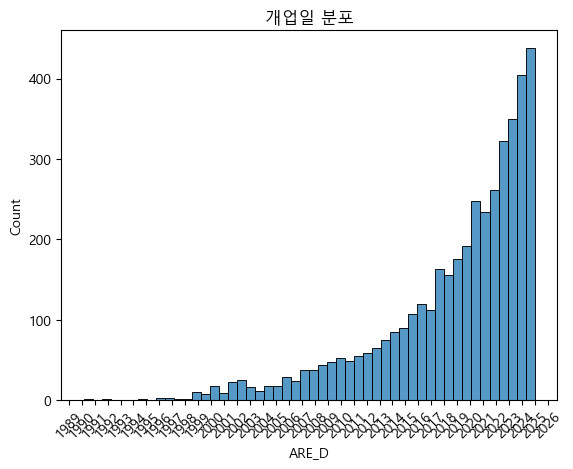

In [45]:
sns.histplot(merchants['ARE_D'], bins=50)
plt.title('개업일 분포')

# x축을 연도 단위로만 표시
plt.gca().xaxis.set_major_locator(mdates.YearLocator())   # 1년 단위 tick
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # 'YYYY' 형식

plt.xticks(rotation=45)  # 보기 좋게 45도 회전 (옵션)
plt.show()

In [46]:
merchants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ENCODED_MCT         4185 non-null   object        
 1   MCT_BSE_AR          4185 non-null   object        
 2   MCT_NM              4185 non-null   object        
 3   MCT_BRD_NUM         542 non-null    object        
 4   MCT_SIGUNGU_NM      4185 non-null   object        
 5   HPSN_MCT_ZCD_NM     4185 non-null   object        
 6   HPSN_MCT_BZN_CD_NM  3138 non-null   object        
 7   ARE_D               4185 non-null   datetime64[ns]
 8   MCT_ME_D            4185 non-null   datetime64[ns]
 9   STATUS              4185 non-null   int64         
 10  DUR_DAYS            4185 non-null   int64         
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 359.8+ KB


In [52]:
merchants[merchants['ARE_D'].dt.year < 2020]['STATUS'].value_counts(normalize=True)

STATUS
1    0.975866
0    0.024134
Name: proportion, dtype: float64

In [53]:
merchants[merchants['ARE_D'].dt.year >= 2020]['STATUS'].value_counts(normalize=True)

STATUS
1    0.964458
0    0.035542
Name: proportion, dtype: float64

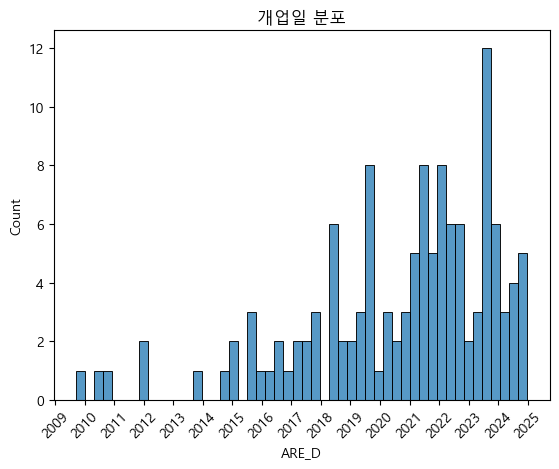

In [37]:
sns.histplot(m_close['ARE_D'], bins=50)
plt.title('개업일 분포')

# x축을 연도 단위로만 표시
plt.gca().xaxis.set_major_locator(mdates.YearLocator())   # 1년 단위 tick
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # 'YYYY' 형식

plt.xticks(rotation=45)  # 보기 좋게 45도 회전 (옵션)
plt.show()

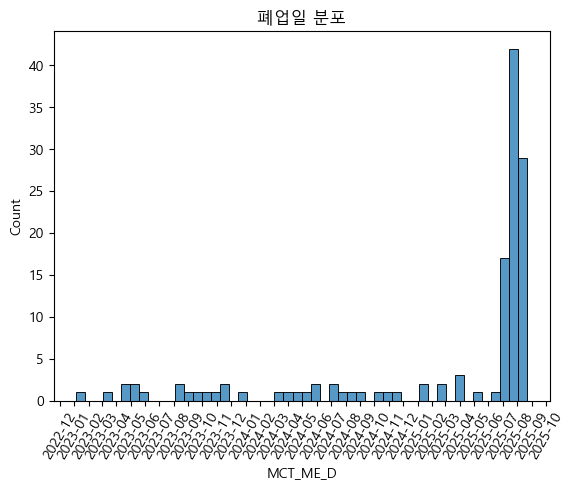

In [38]:
sns.histplot(m_close['MCT_ME_D'], bins=50)
plt.title('폐업일 분포')

# x축을 년-월로 표시
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))   # 1개월 간격
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))   # YYYY-MM 포맷

plt.xticks(rotation=60)  # 보기 좋게 회전
plt.show()

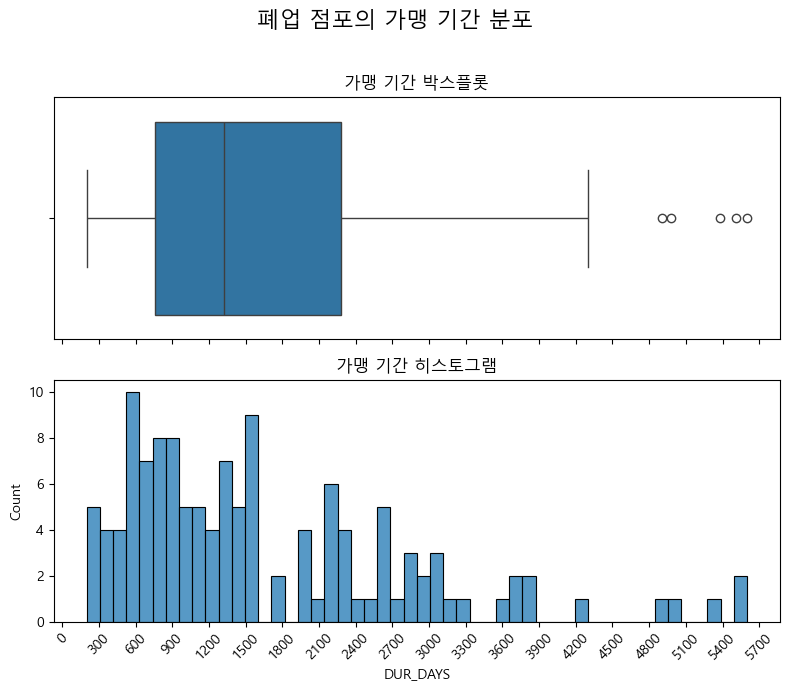

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 2행 1열 subplot, x축 공유
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# 전체 제목
fig.suptitle('폐업 점포의 가맹 기간 분포', fontsize=16)

# (1) 위: 박스플롯
sns.boxplot(x=m_close['DUR_DAYS'], ax=axes[0])
axes[0].set_title('가맹 기간 박스플롯')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(300))


# (2) 아래: 히스토그램
sns.histplot(m_close['DUR_DAYS'], bins=50, ax=axes[1])
axes[1].set_title('가맹 기간 히스토그램')
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(300))
axes[1].tick_params(axis='x', rotation=45)  # x축 라벨 회전

plt.tight_layout(rect=[0, 0, 1, 0.96])  # suptitle과 겹치지 않게 조정
plt.show()

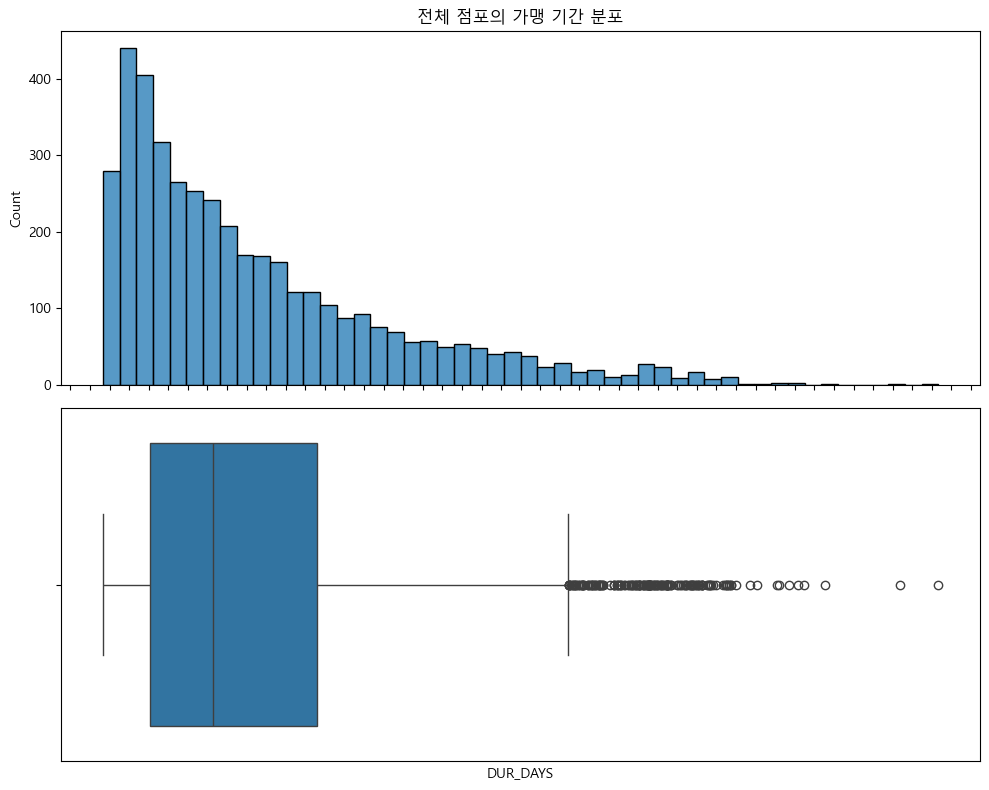

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# (1) 위: 박스플롯
sns.boxplot(x=merchants['DUR_DAYS'], ax=axes[1])
axes[0].set_title('전체 점포의 가맹 기간 분포')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(300))
axes[0].tick_params(axis='x', rotation=45)

# (2) 아래: 히스토그램
sns.histplot(merchants['DUR_DAYS'], bins=50, ax=axes[0])
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(300))
axes[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)  # 위쪽 x축 숨김

plt.tight_layout()
plt.show()

# General EDA

In [17]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 + 음수 표시 정상화
plt.rc('font', family='Malgun Gothic')  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = True  # 음수 기호 표시

In [18]:
# =====================================
# 1. 데이터 불러오기
# =====================================
data1 = merchants.copy()
data2 = pd.read_csv('data/big_data_set2_f.csv', encoding='cp949')
data3 = pd.read_csv('data/big_data_set3_f.csv', encoding='cp949')

In [19]:
# Data set 1 확인
print(data1.info())
data1.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ENCODED_MCT         4185 non-null   object        
 1   MCT_BSE_AR          4185 non-null   object        
 2   MCT_NM              4185 non-null   object        
 3   MCT_BRD_NUM         542 non-null    object        
 4   MCT_SIGUNGU_NM      4185 non-null   object        
 5   HPSN_MCT_ZCD_NM     4185 non-null   object        
 6   HPSN_MCT_BZN_CD_NM  3138 non-null   object        
 7   ARE_D               4185 non-null   datetime64[ns]
 8   MCT_ME_D            4185 non-null   datetime64[ns]
 9   STATUS              4185 non-null   int64         
 10  DUR_DAYS            4185 non-null   int64         
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 359.8+ KB
None


,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,STATUS,DUR_DAYS
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,2013-03-20,2025-09-30,1,4577
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,2013-11-22,2025-09-30,1,4330
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,2014-05-12,2025-09-30,1,4159


In [20]:
# Data set 2 확인
print(data2.info())
data2.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ENCODED_MCT             86590 non-null  object 
 1   TA_YM                   86590 non-null  int64  
 2   MCT_OPE_MS_CN           86590 non-null  object 
 3   RC_M1_SAA               86590 non-null  object 
 4   RC_M1_TO_UE_CT          86590 non-null  object 
 5   RC_M1_UE_CUS_CN         86590 non-null  object 
 6   RC_M1_AV_NP_AT          86590 non-null  object 
 7   APV_CE_RAT              79958 non-null  object 
 8   DLV_SAA_RAT             86590 non-null  float64
 9   M1_SME_RY_SAA_RAT       86590 non-null  float64
 10  M1_SME_RY_CNT_RAT       86590 non-null  float64
 11  M12_SME_RY_SAA_PCE_RT   86590 non-null  float64
 12  M12_SME_BZN_SAA_PCE_RT  86590 non-null  float64
 13  M12_SME_RY_ME_MCT_RAT   86590 non-null  float64
 14  M12_SME_BZN_ME_MCT_RAT  86590 non-null

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2


In [21]:
# Data set 3 확인
print(data3.info())
data3.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86590 non-null  object 
 1   TA_YM                     86590 non-null  int64  
 2   M12_MAL_1020_RAT          86590 non-null  float64
 3   M12_MAL_30_RAT            86590 non-null  float64
 4   M12_MAL_40_RAT            86590 non-null  float64
 5   M12_MAL_50_RAT            86590 non-null  float64
 6   M12_MAL_60_RAT            86590 non-null  float64
 7   M12_FME_1020_RAT          86590 non-null  float64
 8   M12_FME_30_RAT            86590 non-null  float64
 9   M12_FME_40_RAT            86590 non-null  float64
 10  M12_FME_50_RAT            86590 non-null  float64
 11  M12_FME_60_RAT            86590 non-null  float64
 12  MCT_UE_CLN_REU_RAT        86590 non-null  float64
 13  MCT_UE_CLN_NEW_RAT        86590 non-null  float64
 14  RC_M1_

,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


In [22]:
# =====================================
# 2. 결측치 확인
# =====================================
def missing_summary(df, name):
    print(f"--- {name} 결측치 요약 ---")
    print(df.isnull().sum())
    print("\n")

missing_summary(data1, "DATA1") # 4185 중 브랜드코드(3643 null), 업종(1047 null)
missing_summary(data2, "DATA2") # 86590 중 취소율 구간(6632 null)
missing_summary(data3, "DATA3") # 86590 중 null 없음

--- DATA1 결측치 요약 ---
ENCODED_MCT              0
MCT_BSE_AR               0
MCT_NM                   0
MCT_BRD_NUM           3643
MCT_SIGUNGU_NM           0
HPSN_MCT_ZCD_NM          0
HPSN_MCT_BZN_CD_NM    1047
ARE_D                    0
MCT_ME_D                 0
STATUS                   0
DUR_DAYS                 0
dtype: int64


--- DATA2 결측치 요약 ---
ENCODED_MCT                  0
TA_YM                        0
MCT_OPE_MS_CN                0
RC_M1_SAA                    0
RC_M1_TO_UE_CT               0
RC_M1_UE_CUS_CN              0
RC_M1_AV_NP_AT               0
APV_CE_RAT                6632
DLV_SAA_RAT                  0
M1_SME_RY_SAA_RAT            0
M1_SME_RY_CNT_RAT            0
M12_SME_RY_SAA_PCE_RT        0
M12_SME_BZN_SAA_PCE_RT       0
M12_SME_RY_ME_MCT_RAT        0
M12_SME_BZN_ME_MCT_RAT       0
dtype: int64


--- DATA3 결측치 요약 ---
ENCODED_MCT                 0
TA_YM                       0
M12_MAL_1020_RAT            0
M12_MAL_30_RAT              0
M12_MAL_40_RAT           

In [23]:
# =====================================
# 3. 기본 통계 확인
# =====================================
print('--- DATA1 기본 통계 ---')
print(data1.describe())
print()
print('--- DATA2 기본 통계 ---')
print(data2.describe())
print()
print('--- DATA3 기본 통계 ---')
print(data3.describe())

--- DATA1 기본 통계 ---
                               ARE_D                       MCT_ME_D  \
count                           4185                           4185   
mean   2018-10-18 16:51:16.129032192  2025-09-23 16:28:12.903225600   
min              1990-02-28 00:00:00            2023-01-05 00:00:00   
25%              2016-03-15 00:00:00            2025-09-30 00:00:00   
50%              2020-07-31 00:00:00            2025-09-30 00:00:00   
75%              2023-03-28 00:00:00            2025-09-30 00:00:00   
max              2024-12-23 00:00:00            2025-09-30 00:00:00   
std                              NaN                            NaN   

            STATUS      DUR_DAYS  
count  4185.000000   4185.000000  
mean      0.969654   2531.983990  
min       0.000000    199.000000  
25%       1.000000    914.000000  
50%       1.000000   1881.000000  
75%       1.000000   3478.000000  
max       1.000000  12998.000000  
std       0.171559   2102.601376  

--- DATA2 기본 통계 ---
    

In [24]:
data2['TA_YM'].min(), data2['TA_YM'].max()

(202301, 202412)

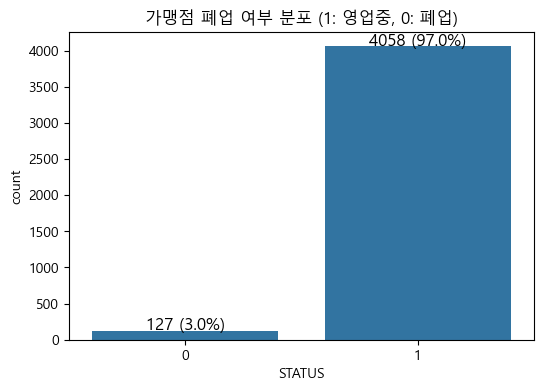

In [25]:
# =====================================
# 4. 폐업 여부 분포 확인 (DATA1)
# =====================================
plt.figure(figsize=(6,4))
ax = sns.countplot(x='STATUS', data=data1)
plt.title('가맹점 폐업 여부 분포 (1: 영업중, 0: 폐업)')

# 전체 데이터 수
total = len(data1)

# 막대 위에 카운트와 백분율 표시
for p in ax.patches:
    count = int(p.get_height())
    percent = count / total * 100
    ax.text(
        p.get_x() + p.get_width()/2., 
        count + 5, 
        f'{count} ({percent:.1f}%)',  # 카운트와 % 표시
        ha='center', fontsize=12
    )

plt.show()

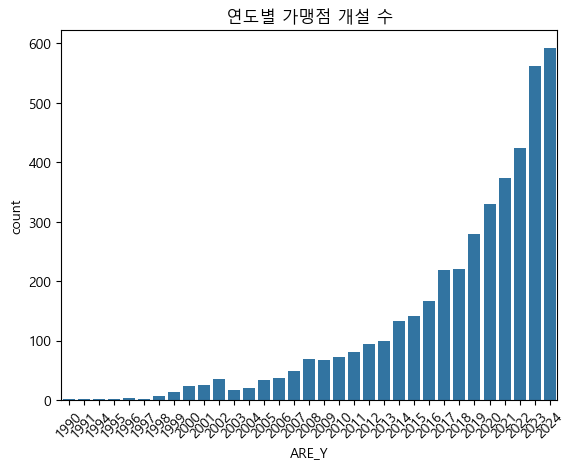

In [26]:
# =====================================
# 5. 개설일 기준 개설 연도 추출
# =====================================
data1['ARE_Y'] = pd.to_datetime(data1['ARE_D']).dt.year
sns.countplot(x='ARE_Y', data=data1)
plt.title('연도별 가맹점 개설 수')
plt.xticks(rotation=45)
plt.show()

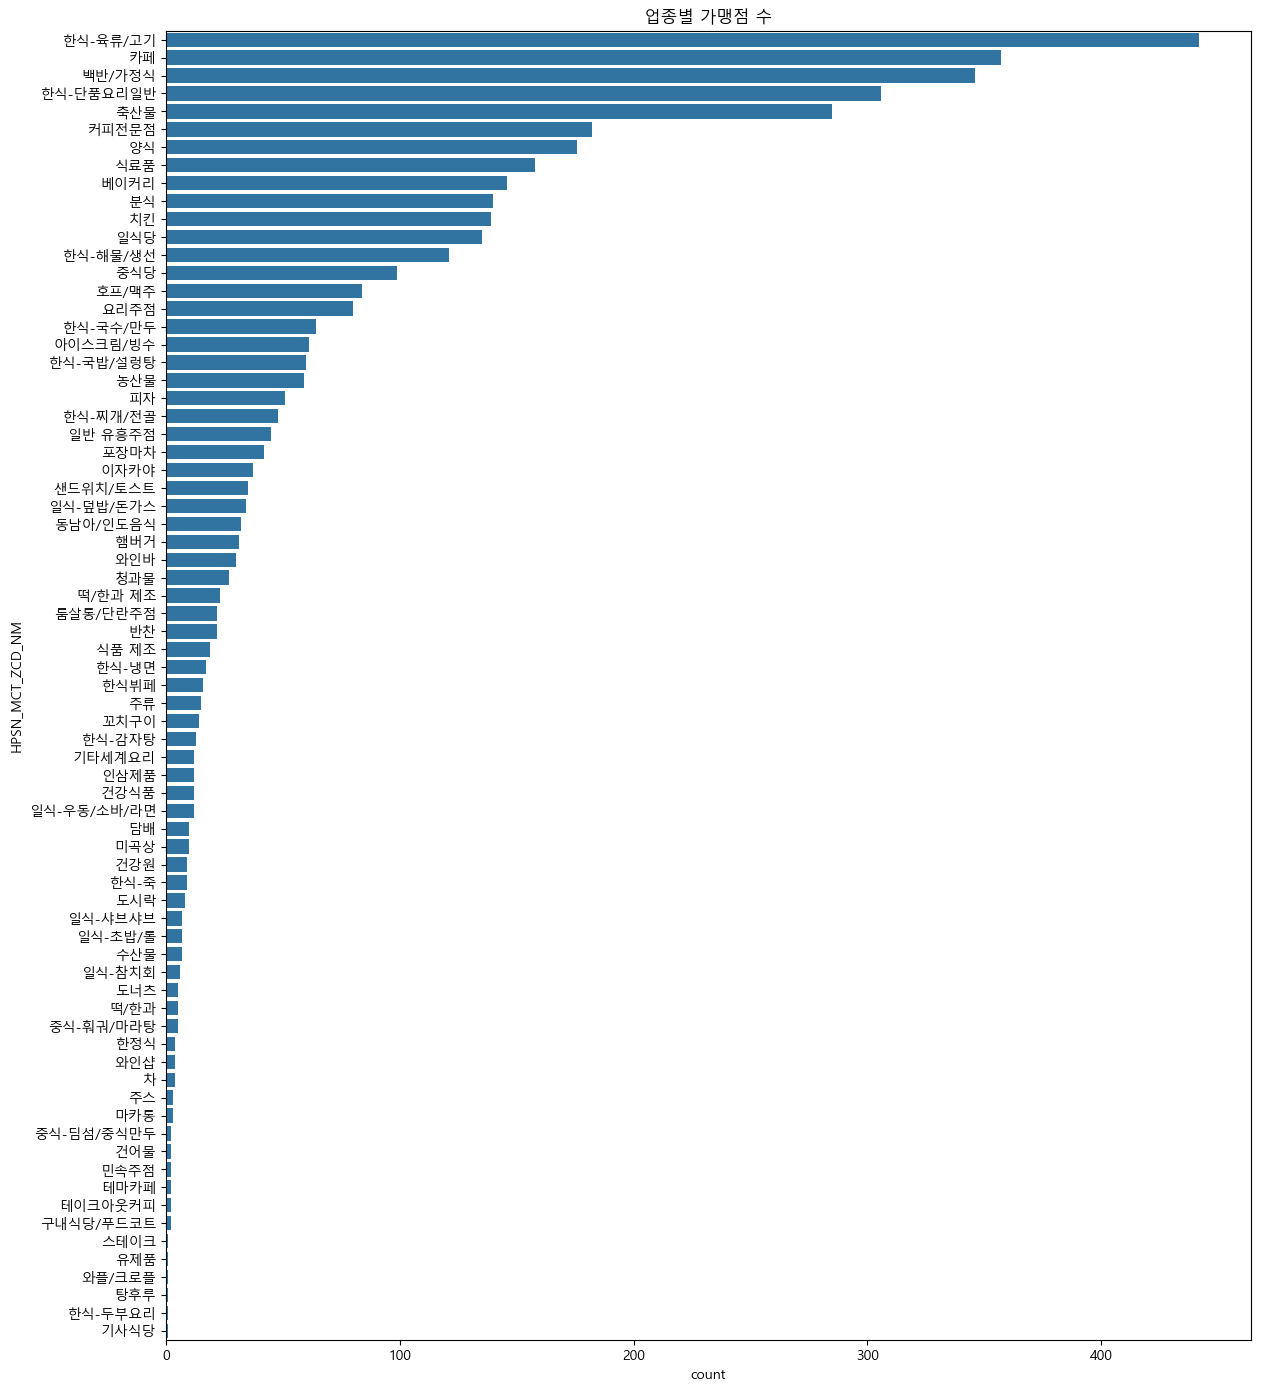

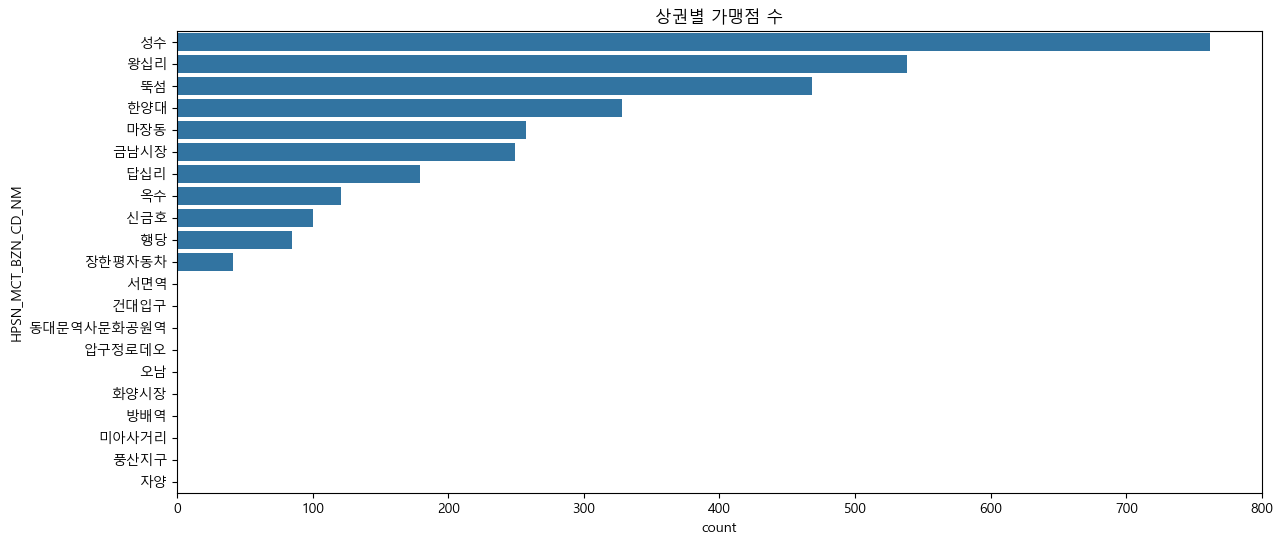

In [27]:
# =====================================
# 6. 상권/업종 분포 확인 (DATA1)
# =====================================
plt.figure(figsize=(14,17))  # 높이를 늘려서 겹침 방지
sns.countplot(
    y='HPSN_MCT_ZCD_NM', 
    data=data1, 
    order=data1['HPSN_MCT_ZCD_NM'].value_counts().index
)
plt.title('업종별 가맹점 수')
plt.show()

plt.figure(figsize=(14,6))
sns.countplot(y='HPSN_MCT_BZN_CD_NM', data=data1, order=data1['HPSN_MCT_BZN_CD_NM'].value_counts().index)
plt.title('상권별 가맹점 수')
plt.show()

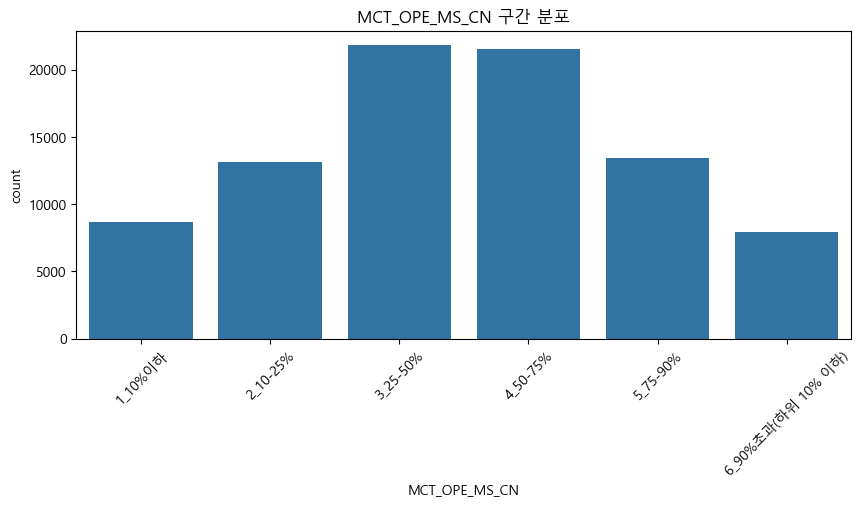

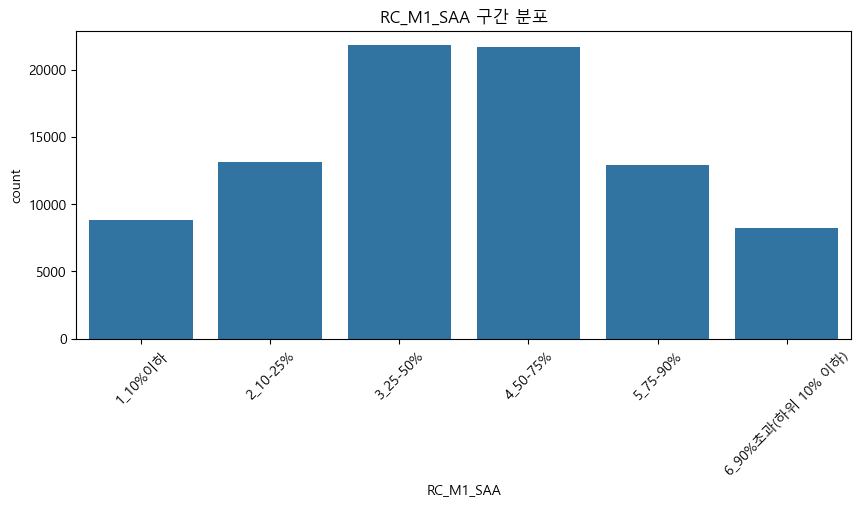

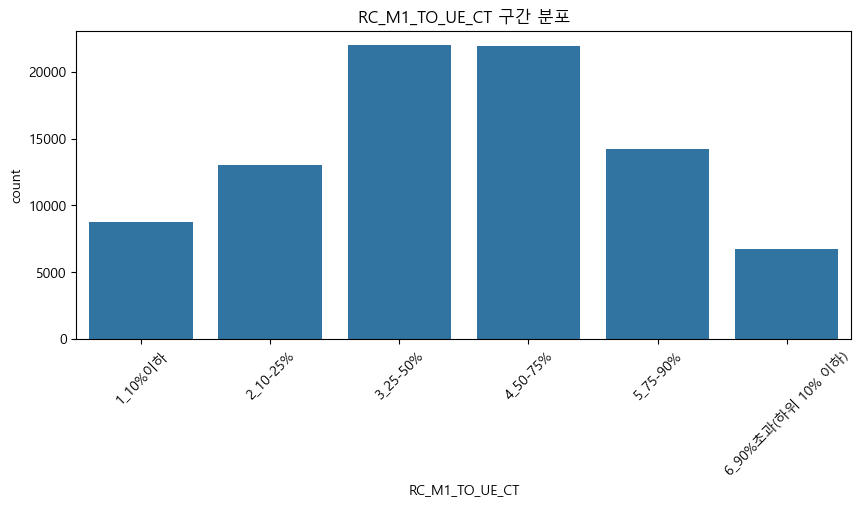

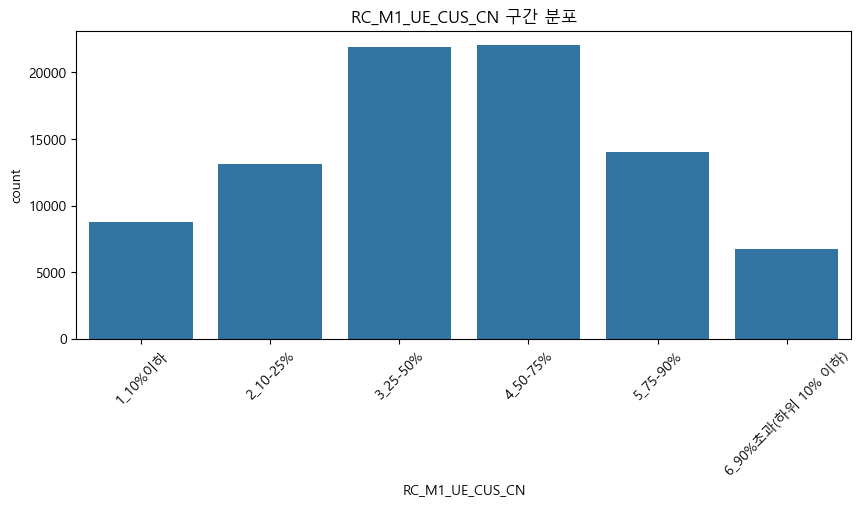

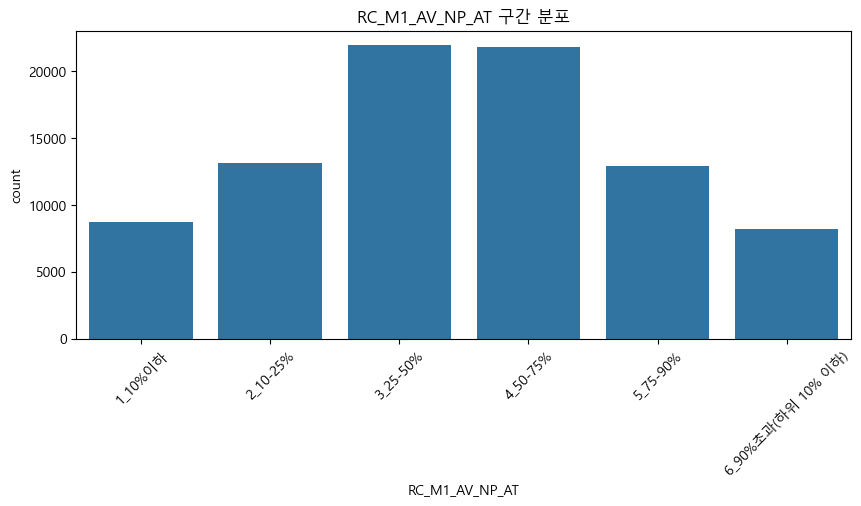

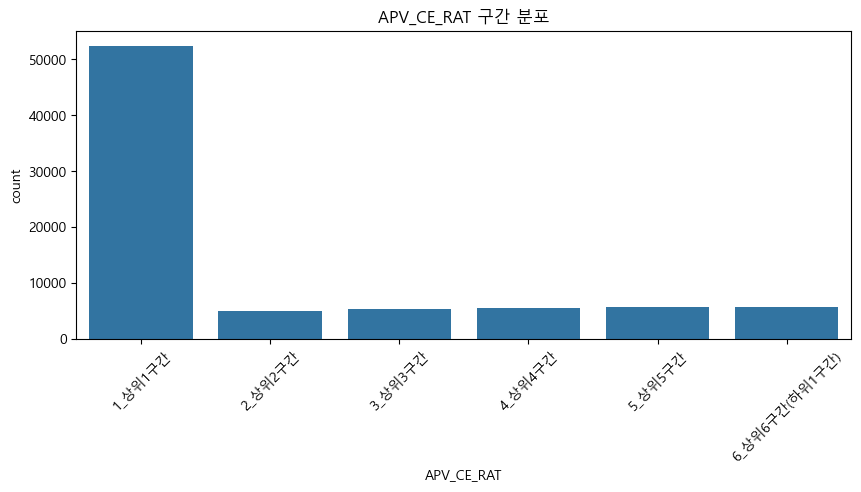

In [28]:
# =====================================
# 7. DATA2: 매출/고객/운영개월수 구간 확인
# =====================================
cols_cat = ['MCT_OPE_MS_CN','RC_M1_SAA','RC_M1_TO_UE_CT','RC_M1_UE_CUS_CN','RC_M1_AV_NP_AT','APV_CE_RAT']
for col in cols_cat:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, data=data2, order=data2[col].value_counts().sort_index().index)
    plt.title(f'{col} 구간 분포')
    plt.xticks(rotation=45)
    plt.show()

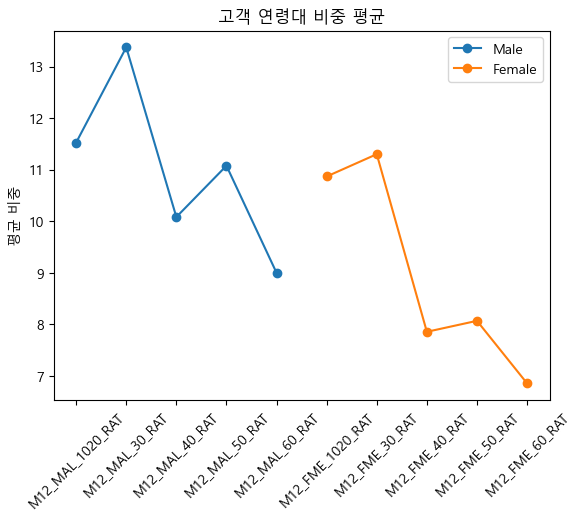

In [29]:
# =====================================
# 8. DATA3: 고객 연령대 분포 확인
# =====================================
age_cols = ['M12_MAL_1020_RAT','M12_MAL_30_RAT','M12_MAL_40_RAT','M12_MAL_50_RAT','M12_MAL_60_RAT',
            'M12_FME_1020_RAT','M12_FME_30_RAT','M12_FME_40_RAT','M12_FME_50_RAT','M12_FME_60_RAT']

data3[age_cols] = data3[age_cols].replace(-999999.9, np.nan)  # 결측치 처리

# 남/여 연령대 평균
male_avg = data3[['M12_MAL_1020_RAT','M12_MAL_30_RAT','M12_MAL_40_RAT','M12_MAL_50_RAT','M12_MAL_60_RAT']].mean()
female_avg = data3[['M12_FME_1020_RAT','M12_FME_30_RAT','M12_FME_40_RAT','M12_FME_50_RAT','M12_FME_60_RAT']].mean()

plt.plot(male_avg.index, male_avg.values, marker='o', label='Male')
plt.plot(female_avg.index, female_avg.values, marker='o', label='Female')
plt.title('고객 연령대 비중 평균')
plt.ylabel('평균 비중')
plt.xticks(rotation=45)
plt.legend()
plt.show()

- 인구수: 실제 지역에 거주하는 거주자 대비 인구비율로 확인

In [30]:
data2_sel = data2[['ENCODED_MCT', 'TA_YM']].sort_values(by=['ENCODED_MCT', 'TA_YM']).reset_index(drop=True)
data3_sel = data3[['ENCODED_MCT', 'TA_YM']].sort_values(by=['ENCODED_MCT', 'TA_YM']).reset_index(drop=True)

In [31]:
# 비교
are_equal = data2_sel.equals(data3_sel)
are_equal

True

In [32]:
# =====================================
# 9. 데이터 결합 (EDA 목적)
# =====================================
# 데이터 병합
data2['ENCODED_MCT'] = data2['ENCODED_MCT'].str.strip()
data3['ENCODED_MCT'] = data3['ENCODED_MCT'].str.strip()

data2['TA_YM'] = pd.to_datetime(data2['TA_YM'], format='%Y%m', errors='coerce')
data3['TA_YM'] = pd.to_datetime(data3['TA_YM'], format='%Y%m', errors='coerce')

df_merge = data2.merge(data3, on=['ENCODED_MCT', 'TA_YM'], how='left')

df_merge.head(3)

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,...,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,000F03E44A,2024-04-01,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,...,4.0182,2.0091,2.0091,4.0182,6.0273,5.00,45.00,12.5,12.5,75.0
1,000F03E44A,2023-12-01,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,...,4.1917,12.5500,0.0000,8.3583,0.0000,0.00,0.00,-999999.9,-999999.9,-999999.9
2,002816BA73,2024-04-01,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,...,1.1616,5.0512,4.2768,4.8752,2.2352,10.66,6.12,23.8,23.8,52.4


In [43]:
df_merge.isna().sum()

ENCODED_MCT                    0
TA_YM                          0
MCT_OPE_MS_CN                  0
RC_M1_SAA                      0
RC_M1_TO_UE_CT                 0
RC_M1_UE_CUS_CN                0
RC_M1_AV_NP_AT                 0
APV_CE_RAT                  6632
DLV_SAA_RAT                    0
M1_SME_RY_SAA_RAT              0
M1_SME_RY_CNT_RAT              0
M12_SME_RY_SAA_PCE_RT          0
M12_SME_BZN_SAA_PCE_RT         0
M12_SME_RY_ME_MCT_RAT          0
M12_SME_BZN_ME_MCT_RAT         0
M12_MAL_1020_RAT            2004
M12_MAL_30_RAT              2004
M12_MAL_40_RAT              2004
M12_MAL_50_RAT              2004
M12_MAL_60_RAT              2004
M12_FME_1020_RAT            2004
M12_FME_30_RAT              2004
M12_FME_40_RAT              2004
M12_FME_50_RAT              2004
M12_FME_60_RAT              2004
MCT_UE_CLN_REU_RAT             0
MCT_UE_CLN_NEW_RAT             0
RC_M1_SHC_RSD_UE_CLN_RAT       0
RC_M1_SHC_WP_UE_CLN_RAT        0
RC_M1_SHC_FLP_UE_CLN_RAT       0
dtype: int

In [34]:
data2.isna().sum()

ENCODED_MCT                  0
TA_YM                        0
MCT_OPE_MS_CN                0
RC_M1_SAA                    0
RC_M1_TO_UE_CT               0
RC_M1_UE_CUS_CN              0
RC_M1_AV_NP_AT               0
APV_CE_RAT                6632
DLV_SAA_RAT                  0
M1_SME_RY_SAA_RAT            0
M1_SME_RY_CNT_RAT            0
M12_SME_RY_SAA_PCE_RT        0
M12_SME_BZN_SAA_PCE_RT       0
M12_SME_RY_ME_MCT_RAT        0
M12_SME_BZN_ME_MCT_RAT       0
dtype: int64

In [35]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ENCODED_MCT               86590 non-null  object        
 1   TA_YM                     86590 non-null  datetime64[ns]
 2   MCT_OPE_MS_CN             86590 non-null  object        
 3   RC_M1_SAA                 86590 non-null  object        
 4   RC_M1_TO_UE_CT            86590 non-null  object        
 5   RC_M1_UE_CUS_CN           86590 non-null  object        
 6   RC_M1_AV_NP_AT            86590 non-null  object        
 7   APV_CE_RAT                79958 non-null  object        
 8   DLV_SAA_RAT               86590 non-null  float64       
 9   M1_SME_RY_SAA_RAT         86590 non-null  float64       
 10  M1_SME_RY_CNT_RAT         86590 non-null  float64       
 11  M12_SME_RY_SAA_PCE_RT     86590 non-null  float64       
 12  M12_SME_BZN_SAA_PC

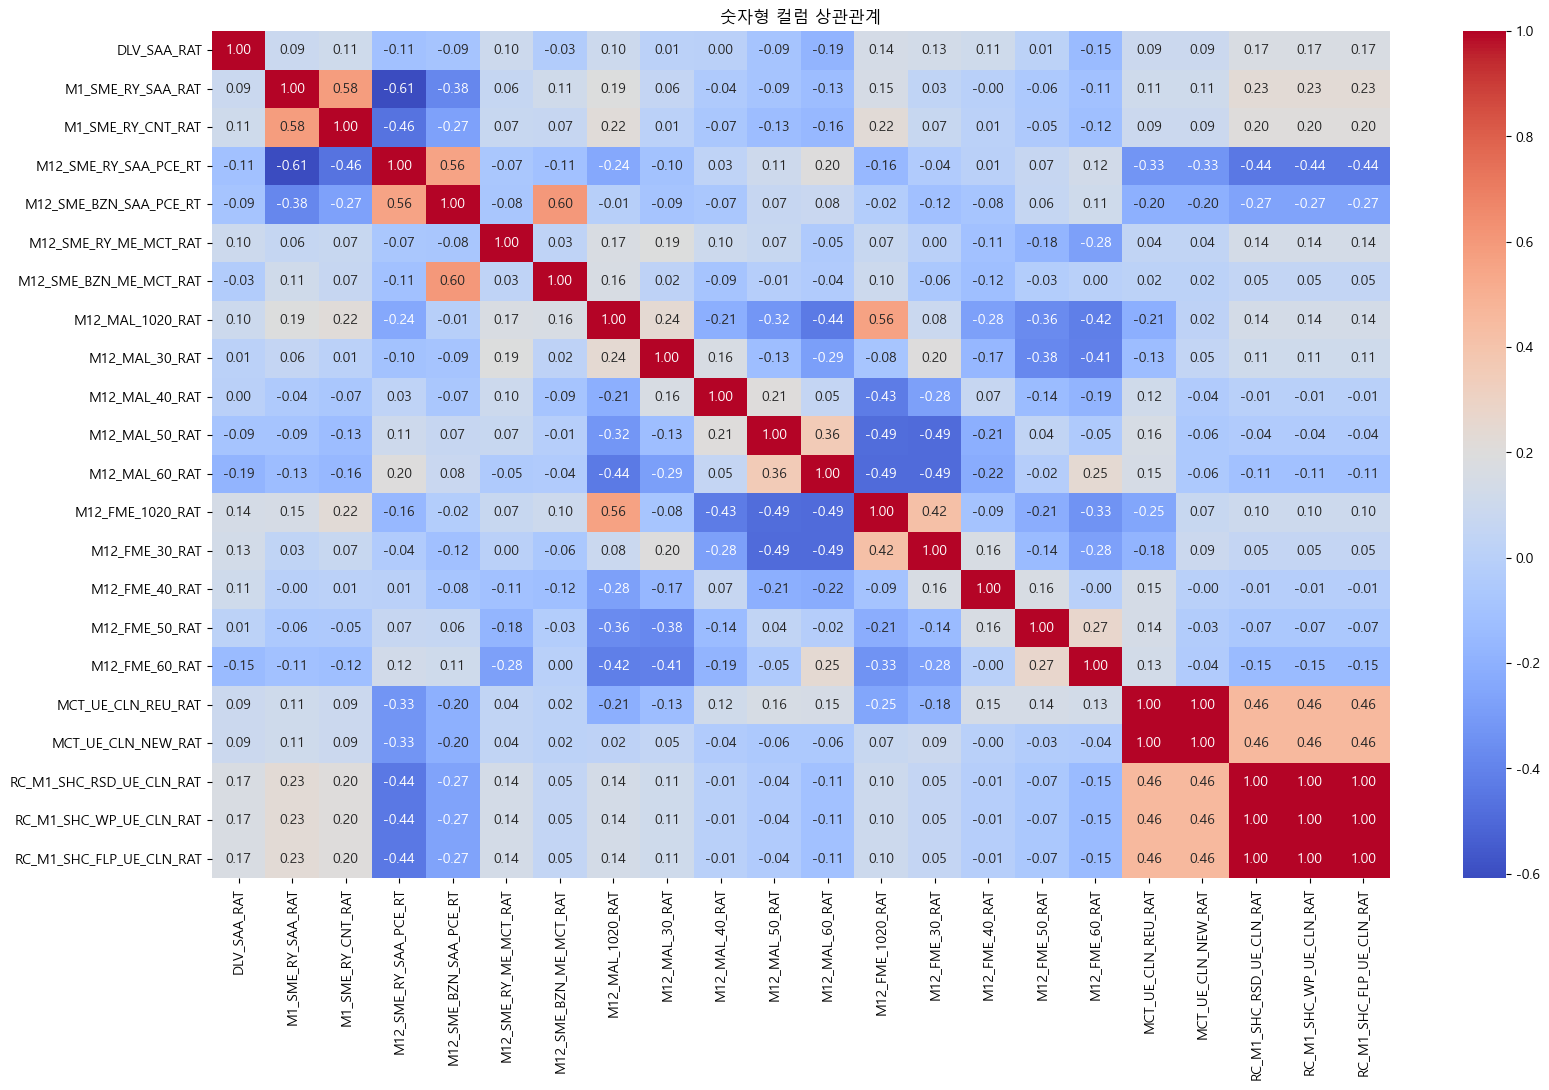

In [44]:
# =====================================
# 10. 상관관계 확인 (숫자형 컬럼)
# =====================================
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

numeric_cols = df_merge.select_dtypes(include=np.number).columns
plt.figure(figsize=(19,11))
sns.heatmap(df_merge[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('숫자형 컬럼 상관관계')
plt.show()